In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import warnings
warnings.filterwarnings('ignore')

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Plot styling
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [2]:
df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (1407328, 6)

Column names: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']

First 5 rows:


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [3]:


# Parse dates properly
df['date'] = pd.to_datetime(df['date'], format='mixed', utc=True)

# Basic info
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)
print("\nDate range:", df['date'].min(), "to", df['date'].max())

Shape: (1407328, 6)

Missing values:
 Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

Data types:
 Unnamed: 0                  int64
headline                   object
url                        object
publisher                  object
date          datetime64[ns, UTC]
stock                      object
dtype: object

Date range: 2009-02-14 00:00:00+00:00 to 2020-06-11 21:12:35+00:00


In [4]:
# Headline length analysis
df['headline_length'] = df['headline'].str.len()
df['word_count'] = df['headline'].str.split().str.len()

print("Headline Character Length Stats:")
print(df['headline_length'].describe())

print("\nHeadline Word Count Stats:")
print(df['word_count'].describe())

Headline Character Length Stats:
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

Headline Word Count Stats:
count    1.407328e+06
mean     1.141671e+01
std      6.352997e+00
min      1.000000e+00
25%      7.000000e+00
50%      1.000000e+01
75%      1.300000e+01
max      7.700000e+01
Name: word_count, dtype: float64


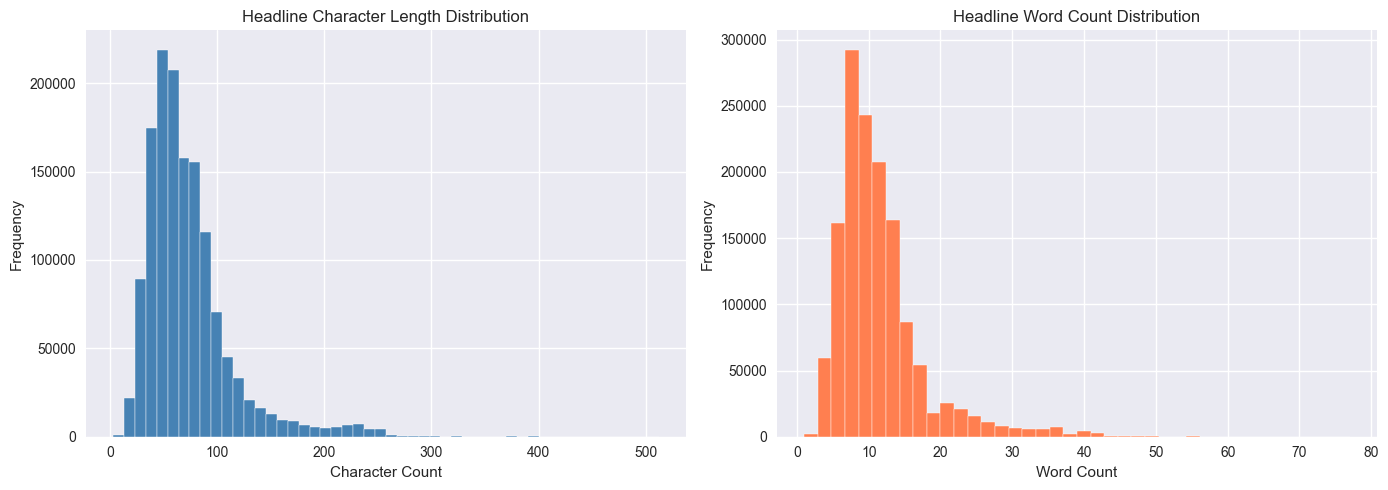

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['headline_length'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Headline Character Length Distribution')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['word_count'], bins=40, color='coral', edgecolor='white')
axes[1].set_title('Headline Word Count Distribution')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../reports/figures/headline_length_distribution.png', dpi=150)
plt.show()

### 📊 Headline Length Analysis

#### Key Findings

**Character Length:**
- The average headline is **73 characters** long (std: 40), with a median of **64 characters**
- 50% of headlines fall between **47 and 87 characters** — consistent with typical news headline conventions
- The distribution is **right-skewed**, with a long tail extending to a maximum of **512 characters**
- The minimum of **3 characters** suggests some data quality issues worth investigating

**Word Count:**
- Headlines average **11 words** (std: 6), with a median of **10 words**
- 50% of headlines contain between **7 and 13 words**
- The distribution follows a **log-normal shape**, peaking around 10 words
- Very few headlines exceed 30 words, with a maximum of 77 words

#### Insight
The tight concentration of headline lengths (7–13 words, 47–87 characters) reflects the standardized, concise nature of financial news writing. The right skew and long tail suggest a minority of articles contain unusually detailed or compound headlines — these may represent earnings reports, regulatory filings, or multi-stock analyses, whic

## Publisher Analysis

#### Frequency & Distribution Analysis:

Total unique publishers: 1034

Top 20 Publishers:
 publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Allie Wickman         18317
Shanthi Rexaline      16640
Craig Jones           16221
Wayne Duggan          12897
Nelson Hem            12590
Name: count, dtype: int64


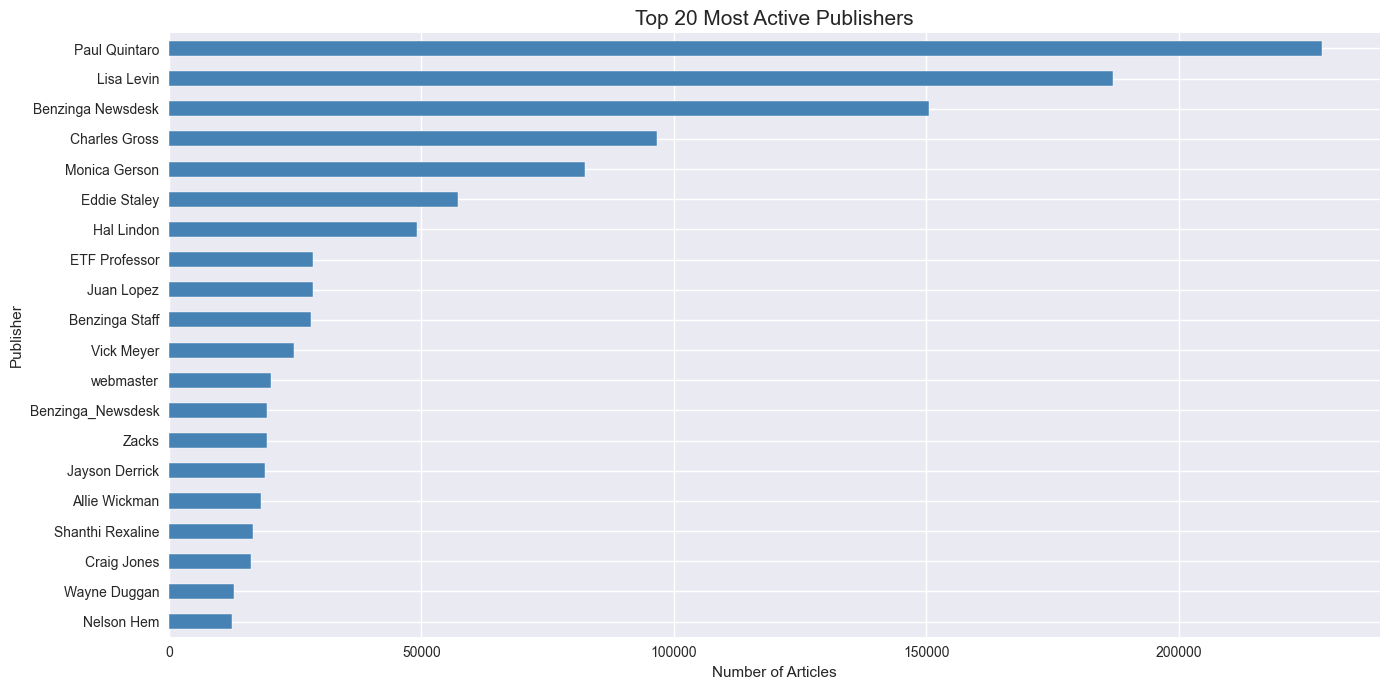

In [9]:
# ── PUBLISHER FREQUENCY ANALYSIS ──────────────────────────────────────────────

# Unique publisher count
print(f"Total unique publishers: {df['publisher'].nunique()}")

# Top 20 publishers by article count
publisher_counts = df['publisher'].value_counts()
top20 = publisher_counts.head(20)
print("\nTop 20 Publishers:\n", top20)

# Plot
plt.figure(figsize=(14, 7))
top20.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 20 Most Active Publishers', fontsize=15)
plt.xlabel('Number of Articles')
plt.ylabel('Publisher')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/top_publishers.png', dpi=150)
plt.show()

####  Email domain extraction

In [11]:
# ── EMAIL DOMAIN EXTRACTION ────────────────────────────────────────────────────

# Normalize publisher names
df['publisher_clean'] = df['publisher'].str.lower().str.strip()

# Extract domain from email-based publisher names
def extract_publisher(name):
    if '@' in str(name):
        return name.split('@')[1].strip()
    return name

df['publisher_clean'] = df['publisher_clean'].apply(extract_publisher)

# Summary
email_mask = df['publisher'].str.contains('@', na=False)
print(f"Articles with email-based publisher names: {email_mask.sum()}")
print(f"Unique domains extracted: {df[email_mask]['publisher_clean'].nunique()}")
print("\nTop 10 email domains:\n", df[email_mask]['publisher_clean'].value_counts().head(10))

Articles with email-based publisher names: 8088
Unique domains extracted: 8

Top 10 email domains:
 publisher_clean
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64


#### Publisher-Stock Heatmap + Publishing Cadence:

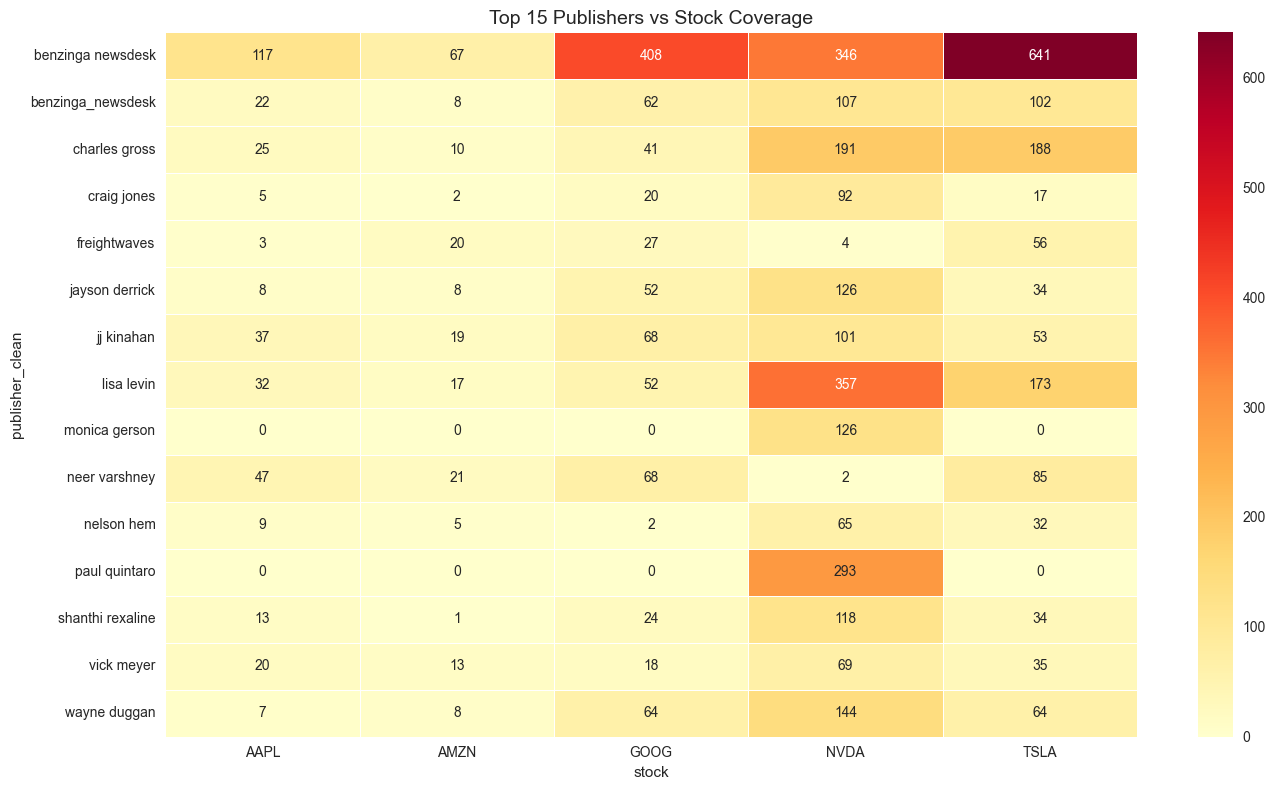

% of articles published during market hours (top 10 publishers):
publisher_clean
etf professor        10.77
benzinga newsdesk     6.27
lisa levin            4.78
hal lindon            1.62
paul quintaro         0.85
eddie staley          0.77
charles gross         0.55
monica gerson         0.29
juan lopez            0.06
benzinga staff        0.02
Name: is_market_hours, dtype: float64


In [12]:
# ── PUBLISHER-STOCK COVERAGE & CADENCE ────────────────────────────────────────

# Filter to our 7 yfinance stocks
yfinance_stocks = ['AAPL', 'AMZN', 'GOOG', 'META', 'MSFT', 'NVDA', 'TSLA']
df_focus = df[df['stock'].isin(yfinance_stocks)]

# Publisher-stock heatmap (top 15 publishers)
top15_pub = df_focus['publisher_clean'].value_counts().head(15).index
heatmap_data = df_focus[df_focus['publisher_clean'].isin(top15_pub)]\
    .groupby(['publisher_clean', 'stock']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='d', linewidths=0.5)
plt.title('Top 15 Publishers vs Stock Coverage', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/publisher_stock_heatmap.png', dpi=150)
plt.show()

# Publishing cadence
df['hour'] = df['date'].dt.hour
df['is_market_hours'] = df['hour'].between(13, 20)  # 9am-4pm EST = 13-20 UTC

top10_pub = publisher_counts.head(10).index
cadence = df[df['publisher'].isin(top10_pub)]\
    .groupby('publisher_clean')['is_market_hours'].mean() * 100

print("% of articles published during market hours (top 10 publishers):")
print(cadence.sort_values(ascending=False).round(2))

## 📰 Publisher Analysis — Key Findings

- **1,034 unique publishers**, heavily concentrated — top 5 dominate the majority of articles
- **Paul Quintaro (228K)** and **Lisa Levin (187K)** alone represent a significant portion of the dataset, introducing potential **sentiment bias**
- `Benzinga Newsdesk` vs `Benzinga_Newsdesk` is a **data quality flag** — needs merging before modeling
- **8,088 email-based publishers** resolve to just 8 domains, almost entirely `benzinga.com` — confirming this is largely a Benzinga-sourced dataset
- **TSLA and NVDA** are the most covered stocks — correlation analysis will be most reliable for these two
- Most news is published **outside market hours** — sentiment likely influences **next day's price** rather than same-day close

> ⚠️ **Preprocessing Flag:** `Benzinga_Newsdesk` and `Benzinga Newsdesk` are the same publisher
> split by an underscore. This will be normalized in the preprocessing stage before modeling.